# Taller 4 · Codificación PCM: LPCM, DPCM y Delta Modulation

**Asignatura:** Teoría de la Información y Procesado de Señal  
**Grado en Ciencia e Ingeniería de Datos (GCED) — Universidad de A Coruña**  
**Duración:** 2 horas  
**Modalidad:** Jupyter Notebook con asistencia de IA (GitHub Copilot)

---

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

1. Implementar una cadena **LPCM** (cuantificación directa de cada muestra).
2. Implementar **DPCM** con predicción simple y cuantificación del error de predicción.
3. Implementar **Delta Modulation (DM)** y entender sus requisitos de $F_s$.
4. Identificar **granular noise** y **slope overload** en DM.
5. Comparar MSE, SQNR y **régimen binario** entre los tres métodos.
6. Razonar sobre **cuándo cada método es más apropiado**.

---

## Entregables

- Notebook ejecutado completo (**Run All**) sin errores.
- Figuras correctamente etiquetadas (título, ejes, unidades).
- Secciones de **explicación** completadas con razonamiento propio.
- Respuestas a las preguntas de control.

---

## 🎯 Reto central del taller

> **A igualdad de calidad percibida (20~23 dB de SQNR), ¿qué esquema de codificación es más eficiente en términos de tasa binaria y por qué?**
>
> La codificación PCM (Pulse Code Modulation) convierte una señal cuantificada en una secuencia de bits. Pero no todos los esquemas PCM son iguales: algunos explotan la **redundancia temporal** de la señal para ser más eficientes. Este taller compara tres variantes para que lo compruebes experimentalmente.

---

## Metodología de trabajo con IA

En este curso **puedes y debes usar IA**, pero siguiendo estas reglas:

| Qué puede hacer la IA | Qué debes hacer tú |
|----------------------|--------------------|
| Generar código | Entenderlo y validarlo |
| Sugerir implementaciones | Diseñar el experimento |
| Completar sintaxis | Interpretar los resultados |

### Estructura obligatoria de cada bloque

1. **Implementación**: código generado (con o sin IA).
2. **Validación**: al menos un `assert` o comprobación numérica/visual.
3. **Explicación**: 2–5 líneas en tus propias palabras explicando *qué* ocurre y *por qué*.

> **Mensaje clave:** *La IA te ayuda a escribir código, pero no a entender señales. Eso es tu trabajo.*

---

## Identificación del estudiante

Completa los siguientes campos con tu información personal:

- **Apellidos:** Martínez Martínez

- **Nombre:** Jimena

- **Email UDC:** jimena.martinez@udc.es

---

## 0. Setup inicial

Ejecuta esta celda para importar las librerías y reutilizar el cuantificador del Taller 3.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

# Cuantificador uniforme del Taller 3 (lo reutilizamos)
def cuantificador_uniforme(x, B, xmin, xmax):
    """
    Cuantificador uniforme con REDONDEO (mid-rise).
    x_q, Delta = cuantificador_redondeo(x, B, xmin, xmax)
    
    x: valor de entrada
    B: número de bits
    xmin, xmax: rango de cuantificación
    x_q: valor cuantificado""" 

    rango = xmax - xmin
    L= 2 ** B
    Delta = rango / L

    l = np.floor((x - xmin) / Delta).astype(int)
    l = np.clip(l, 0, L - 1) # Asegura que l esté dentro del rango válido [0, L-1]
    
    x_q = l * Delta + xmin + Delta / 2

    return x_q, Delta

# Función para calcular MSE y SQNR
def calcular_metricas(x_orig, x_q):
    """Calcula MSE y SQNR entre señal original y reconstruida."""
    e = x_orig - x_q
    MSE = np.mean(e**2)
    P_x = np.mean(x_orig**2)
    SQNR_db = 10 * np.log10(P_x / MSE) if MSE > 0 else np.inf
    return MSE, SQNR_db

print("✓ Entorno listo (incluye funciones de cuantificador del Taller 3 y de cálculo de métricas).")

✓ Entorno listo (incluye funciones de cuantificador del Taller 3 y de cálculo de métricas).


---

## Contexto teórico: La familia PCM

La conversión analógico-digital (ADC) tiene tres etapas:

$$x_a(t) \xrightarrow{\text{Muestreo}} x(n) \xrightarrow{\text{Cuantificación}} x_q(n) \xrightarrow{\text{Codificación}} \text{bits}$$

En el Taller 3 estudiamos la cuantificación. Ahora nos centramos en **cómo codificar** las muestras cuantificadas en bits. La familia **PCM** (Pulse Code Modulation) agrupa varios métodos:

| Método | ¿Qué cuantifica? | Bits/muestra | Explota correlación |
|--------|-------------------|--------------|---------------------|
| **LPCM** | Cada muestra directamente | $B$ | No |
| **DPCM** | La diferencia $d[n] = x[n] - \hat{x}[n]$ | $B$ | Sí |
| **DM** | Solo el signo del error (subir/bajar) | 1 | Sí (extremo) |

**Idea clave:** Si la señal tiene **correlación temporal** (muestras consecutivas parecidas), el error de predicción tiene menor rango que la señal original. Cuantificar ese error con los mismos $B$ bits da **mejor calidad**.

**Régimen binario:** $R_b = B \cdot F_s$ bits/segundo. A menor $B$ (o menor $F_s$), menor ancho de banda necesario.

---

## Parte 1: Señales de partida

### Bloque 1 · Generación de señal compuesta

---

#### 📝 Hipótesis previa (COMPLETA ANTES de implementar/ejecutar)

**Preguntas:**

- Si las muestras consecutivas se parecen mucho (alta correlación), ¿qué método se beneficiaría? El método que más se beneficia es DPCM, porque codifica la diferencia entre muestras consecutivas. Si las muestras son muy parecidas, esa diferencia es pequeña y necesita menos rango para cuantificarse, lo que reduce el error.
- ¿Una señal compuesta por la suma de dos sinusoidales tendrá más o menos correlación temporal que ruido blanco? Tendrá mucho más correlación temporal que el ruido blanco. El ruido blanco es completamente aleatorio y las muestras consecutivas no tienen relación entre sí.

---

**Parámetros:**
- Señal compuesta por la suma de dos señales seno con frecuencias: $F_1 = 2$ Hz, $F_2 = 7$ Hz y amplitudes $A_1 = 1$, $A_2 = 0.5$.
- Duración: 2 segundos
- Escalar para que $\max|x| = 0.9$

**Tareas:**
1. Genera dos versiones discretas de la señal compuesta (suma de dos sinusoides) con frecuencias de muestreo $F_s = 100$ Hz y $F_s = 400$ Hz.
2. Escala al rango adecuado para evitar saturación.
3. Represéntala.

In [3]:
# === PARÁMETROS ===
F_s100=100
F_s400=400

# Parámetros de la señal compuesta
T = 2             # segundos
F1, F2 = 2, 7     # Hz
A1, A2 = 1.0, 0.5 # Amplitudes

In [4]:
# N_100, N_400: número de muestras, para Fs=100 Hz y Fs=400 Hz respectivamente
# n_100, n_400: vector de índices de muestra, para Fs=100 Hz y Fs=400 Hz respectivamente
N_100 = int(F_s100 * T)
n_100 = np.arange(N_100)
N_400 = int(F_s400 * T)
n_400 = np.arange(N_400)

# TODO: Genera las señales compuestas (suma de dos sinusoides),
# x_raw100 y x_raw400 con Fs=100 Hz y Fs=400 Hz respectivamente.
t100 = n_100 / F_s100
t400 = n_400 / F_s400

x_raw100 = A1*np.sin(2*np.pi*F1*t100) + A2*np.sin(2*np.pi*F2*t100)
x_raw400 = A1*np.sin(2*np.pi*F1*t400) + A2*np.sin(2*np.pi*F2*t400)

# TODO: Escala para obtener señal x_100 y x_400, con max(|x_100|) = max(|x_400|) = 0.9
x_100 = 0.9 * x_raw100 / np.max(np.abs(x_raw100))
x_400 = 0.9 * x_raw400 / np.max(np.abs(x_raw400))

✓ Señal de 2 segundos generada con F_s=100: 200 muestras, rango [-0.900, 0.900]
✓ Señal de 2 segundos generada con F_s=400: 800 muestras, rango [-0.900, 0.900]


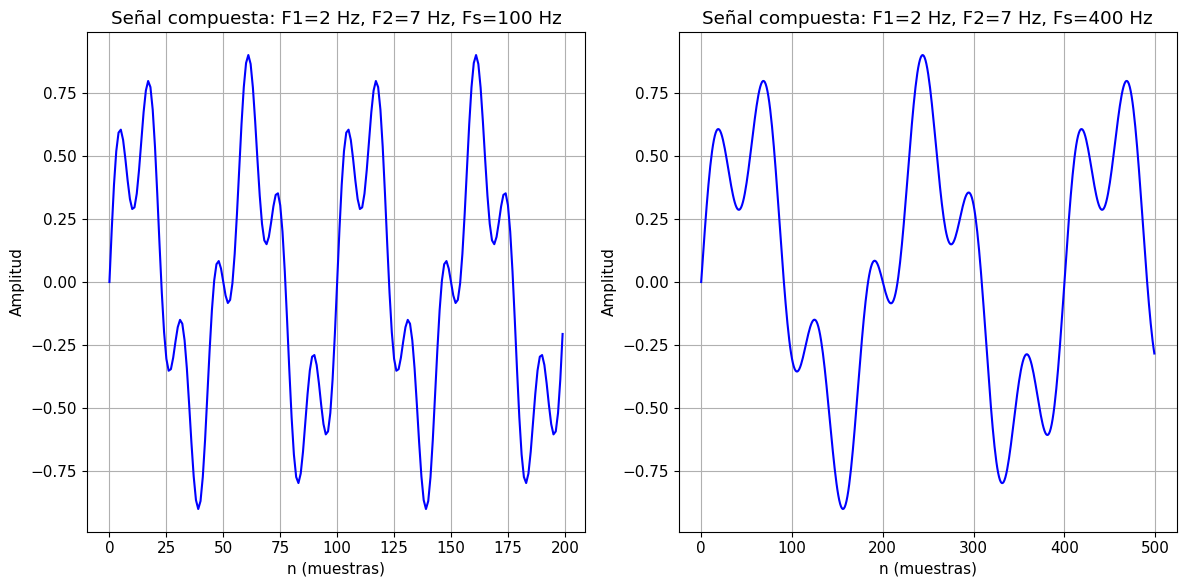

In [5]:
# === VALIDACIÓN ===
assert x_100 is not None, "Genera la señal x_100"
assert x_400 is not None, "Genera la señal x_400"
assert len(x_100) == N_100 and len(x_400) == N_400, f"Las señales debe tener {N_100} y {N_400} muestras"
assert np.max(np.abs(x_100)) <= 0.9001, f"La amplitud máxima debe ser ≤ 0.9, es {np.max(np.abs(x_100)):.3f}"
assert np.max(np.abs(x_400)) <= 0.9001, f"La amplitud máxima debe ser ≤ 0.9, es {np.max(np.abs(x_400)):.3f}"
assert np.max(np.abs(x_100)) > 0.89, "La señal debe estar escalada para max ≈ 0.9"
assert np.max(np.abs(x_400)) > 0.89, "La señal debe estar escalada para max ≈ 0.9"

print(f"✓ Señal de {T} segundos generada con F_s={F_s100}: {N_100} muestras, rango [{np.min(x_100):.3f}, {np.max(x_100):.3f}]")
print(f"✓ Señal de {T} segundos generada con F_s={F_s400}: {N_400} muestras, rango [{np.min(x_400):.3f}, {np.max(x_400):.3f}]") 

# Representa

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(n_100[:500], x_100[:500], 'b-')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.title(f'Señal compuesta: F1={F1} Hz, F2={F2} Hz, Fs={F_s100} Hz')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_400[:500], x_400[:500], 'b-')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.title(f'Señal compuesta: F1={F1} Hz, F2={F2} Hz, Fs={F_s400} Hz')
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Por qué una señal compuesta (con correlación temporal) es útil para comparar métodos PCM?**

*Tu respuesta:*

```
Una señal compuesta formada por sinusoides presenta alta correlación temporal, es decir, las muestras consecutivas son similares.
Esto permite evaluar mejor los métodos como DPCM o DM, que explotan la relación entre muestras para codificar diferencias en lugar de valores absolutos. Así se puede observar claramente la mejora respecto al PCM básico.
```

**2. ¿Qué significa "correlación temporal" intuitivamente? ¿Las muestras consecutivas de esta señal se parecen?**

*Tu respuesta:*

```
La correlación temporal significa que las muestras cercanas en el tiempo están relacionadas o son parecidas.
En esta señal las muestras sí se parecen, porque las sinusoides cambian de forma gradual. Por eso la señal evoluciona suavemente y no presenta cambios bruscos entre muestras.
```

### 🔍 Checkpoint del profesor (Parada 1)

- [ ] Señal compuesta generada, escalada a $\pm 0.9$
- [ ] Assert pasando sin errores

---

## Parte 2: LPCM (Linear PCM) — Cuantificación directa

### Contexto teórico

LPCM cuantifica **cada muestra independientemente** usando $B$ bits:
- No tiene en cuenta el valor de muestras anteriores ni posteriores
- Régimen binario: $R_b = B \cdot F_s$ bits/segundo
- Es el método más simple pero **no explota la correlación temporal**

**Ejemplo real:** El audio en formato WAV sin comprimir usa LPCM (16 bits, 44100 Hz → $R_b = 705{,}600$ bits/s por canal).

### Bloque 2 · Implementación de LPCM

---

#### 📝 Hipótesis previa

**Pregunta:** Con $B = 4$ bits 
- ¿Régimen binario para cada señal?:  Para Fs=100 Hz, 400 bits/s. Para Fs=400 Hz, 1600 bits/s.

---

**Tareas:**
1. Cuantifica las señales, con las dos frecuencias de muestreo anteriores, con el cuantificador uniforme (ya implementado en el setup).
2. Calcula los regímenes binarios R_b_100 y R_b_200, para cada señal respectivamente.
3. Calcula MSE_100 y MSE_400, para cada señal respectivamente.
4. Calcula SQNR_100 y SQNR_400, para cada señal respectivamente.
4. Representa las señales originales vs la cuantificadas (zoom de 200 muestras).

In [6]:
# === IMPLEMENTACIÓN ===
B_lpcm_100 = B_lpcm_400 = 4  # bits

# TODO: Calcula el régimen binario, Rb_lpcm_100 y Rb_lpcm_400, para el cuantificador uniforme con B=4 bits
Rb_lpcm_100 = B_lpcm_100 * F_s100
Rb_lpcm_400 = B_lpcm_400 * F_s400

# TODO: Cuantifica la señal x_100 usando cuantificador_uniforme y su error de cuantización, x_lpcm_100, Delta_lpcm_100, e_lpcm_100
# Cuantifica x_400 usando cuantificador_uniforme y su error de cuantización, x_lpcm_400, Delta_lpcm_400, e_lpcm_400
x_lpcm_100, Delta_lpcm_100 = cuantificador_uniforme(x_100, B_lpcm_100, -0.9, 0.9)
x_lpcm_400, Delta_lpcm_400 = cuantificador_uniforme(x_400, B_lpcm_400, -0.9, 0.9)

e_lpcm_100 = x_100 - x_lpcm_100
e_lpcm_400 = x_400 - x_lpcm_400

# TODO: Calcula el MSE y la SQNR para x_100 y x_400, usando la función calcular_metricas
# MSE_lpcm_100, SQNR_lpcm_100, MSE_lpcm_400, SQNR_lpcm_400, según se trate de las señales x_100 o x_400
MSE_lpcm_100, SQNR_lpcm_100 = calcular_metricas(x_100, e_lpcm_100)
MSE_lpcm_400, SQNR_lpcm_400 = calcular_metricas(x_400, e_lpcm_400)

In [7]:
# === VALIDACIÓN ===
assert x_lpcm_100 is not None, "Cuantifica la señal x_100"
assert x_lpcm_400 is not None, "Cuantifica la señal x_400"
assert Rb_lpcm_100 == B_lpcm_100 * F_s100, f"Régimen binario incorrecto: {Rb_lpcm_100} bits/s, debe ser {B_lpcm_100 * F_s100} bits/s"
assert Rb_lpcm_400 == B_lpcm_400 * F_s400, f"Régimen binario incorrecto: {Rb_lpcm_400} bits/s, debe ser {B_lpcm_400 * F_s400} bits/s"
assert MSE_lpcm_100 is not None and MSE_lpcm_100 > 0, "Calcula el MSE de x_100"
assert SQNR_lpcm_100 is not None and SQNR_lpcm_100 > 0, "Calcula la SQNR de x_100"
assert MSE_lpcm_400 is not None and MSE_lpcm_400 > 0, "Calcula el MSE de x_400"
assert SQNR_lpcm_400 is not None and SQNR_lpcm_400 > 0, "Calcula la SQNR de x_400"

print(f"=== LPCM (B={B_lpcm_100} bits) para x_100 ===")
print(f"Δ = {Delta_lpcm_100:.4f}")
print(f"MSE: {MSE_lpcm_100:.6f}")
print(f"SQNR: {SQNR_lpcm_100:.2f} dB")
print(f"Régimen binario: {Rb_lpcm_100} bits/s")
print("")
print(f"=== LPCM (B={B_lpcm_400} bits) para x_400 ===")
print(f"Δ = {Delta_lpcm_400:.4f}")
print(f"MSE: {MSE_lpcm_400:.6f}")
print(f"SQNR: {SQNR_lpcm_400:.2f} dB")
print(f"Régimen binario: {Rb_lpcm_400} bits/s")

=== LPCM (B=4 bits) para x_100 ===
Δ = 0.1125
MSE: 0.226420
SQNR: 0.10 dB
Régimen binario: 400 bits/s

=== LPCM (B=4 bits) para x_400 ===
Δ = 0.1125
MSE: 0.229078
SQNR: 0.05 dB
Régimen binario: 1600 bits/s


### ✍️ Explicación (OBLIGATORIA)

**1. ¿Ves alguna diferencia importante al cuantificar las señales x_100 y x_400 con LPCM? Da una explicación.**

*Tu respuesta:*

```
Sí, se observa que el error (MSE) y la SQNR son muy parecidos en ambas señales. Esto ocurre porque en LPCM cada muestra se cuantifica de forma independiente y se utiliza el mismo número de bits (4 bits) y el mismo rango de cuantificación, por lo que el pase de cuantificación delta es el mismo en ambas señales.
La diferencia principal aparece en el régimen binario. La señal x_400 tiene un régimen mayor porque se muestra a una frecuencia cuatro veces mayor.
```

---

## Parte 3: DPCM (Differential PCM) — Cuantificación del error de predicción

### Contexto teórico

DPCM explota la **correlación temporal** de la señal:

1. **Predice** la muestra actual a partir de las anteriores: $\hat{x}[n] = x_q[n-1]$ (predictor orden 1)
2. **Calcula** la diferencia: $d[n] = x[n] - \hat{x}[n]$
3. **Cuantifica** la diferencia (que tiene rango dinámico menor que la señal): $d_q[n] = Q[d[n]]$
4. **Reconstruye** en el decodificador: $x_q[n] = \hat{x}[n] + d_q[n]$

NOTA: en ocasiones, la diferencia, $d(n)$, se interpreta como un error de predicción, ya que, en el fondo, se trata del error que comete la predicción $\hat{x}[n]$ respecto a la señal original $x(n)$ . No confundamos esta denominación de la señal diferencia con el error de cuantificación, que es la señal $e(n)$ que ya conocemos.

**¿Por qué funciona?** Si la señal varía lentamente (alta correlación), el error de predicción $d[n]$ es pequeño. Cuantificar un valor pequeño con los mismos $B$ bits da **menor error de cuantificación** → mejor SQNR.

En el decodificador se usa $x_q[n-1]$ (la muestra cuantificada o reconstruida), NO $x[n-1]$ (la original). Esto evita que el error se acumule sin control (el codificador y decodificador "ven" lo mismo).

| Variable | Codificador | Decodificador |
|----------|-------------|---------------|
| Predicción | $\hat{x}[n] = x_q[n-1]$ | $\hat{x}[n] = x_q[n-1]$ |
| Diferencia | $d[n] = x[n] - \hat{x}[n]$ | (recibe $d_q[n]$) |
| Reconstrucción | $x_q[n] = \hat{x}[n] + d_q[n]$ | $x_q[n] = \hat{x}[n] + d_q[n]$ |

### Bloque 3 · Implementación de DPCM

---

#### 📝 Hipótesis previa

**Pregunta:** Si la señal cambia de forma "suave" (muestras consecutivas parecidas):
- La diferencia $d[n] = x[n] - x[n-1]$ será ¿grande o pequeño? Pequeña.
- ¿Necesitarás más o menos rango para cuantificar $d[n]$ comparado con $x[n]$? Menos rango porque la diferencia entre muestras consecutivas es pequeña.
- A igualdad de bits, ¿DPCM debería dar mejor o peor SQNR que LPCM? Mejor SQNR porque se cuantifica una señal con un menor rango dinámico.

---

**Tareas:**
1. Implementa el bucle de DPCM (predictor de orden 1).
2. Elige un rango adecuado para cuantificar de la señal diferencia.
3. Calcula métricas y compara con LPCM.

**Pistas:**
- En la primera muestra ($n = 0$), vamos a suponer que la predicción es $\hat{x}[0] = 0$.
- El rango del cuantificador de la diferencia se puede estimar como: `d_range = max(|diff(x)|) * 1.5`
- Usa el `cuantificador_uniforme` del setup con `xmin=-d_range, xmax=d_range`.

In [8]:
# === Parámetros ===
B_dpcm_100 = B_dpcm_400 = 2

In [9]:
# === IMPLEMENTACIÓN ===
def dpcm_encode_decode(x, B):
    """
    DPCM con predictor de orden 1: x_hat[n] = x_rec[n-1]
    
    Parámetros:
        x: señal original
        B: bits para cuantificar el error
    
    Retorna:
        x_q: señal reconstruida
        d_range: rango usado
    """
    N = len(x)
    x_q = np.zeros(N)
    
    # TODO: Estimar rango de la señal diferencia y considera que el rango estará dentro de [-d_range, d_range)
    # donde d_range = max(|x[n] - x[n-1]|) * 1.5
    diff_signal = np.diff(x)
    d_range = np.max(np.abs(diff_signal)) * 1.5
    
    for i in range(N):
        # TODO: Implementa el bucle DPCM
        # 1. Predicción: x_hat = x_q[i-1] (o 0 si i==0)
        # 2. Error de predicción: d = x[i] - x_hat
        # 3. Cuantifica uniformemente con rendondeo, haciendo uso de la función de cuantificación anterior
        # 4. Reconstruye: x_q[i] = x_hat + d_q
        if i == 0:
            x_hat = 0
        else:
            x_hat = x_q[i-1]
        
        d = x[i] - x_hat

        d_q, _ = cuantificador_uniforme(np.array([d]), B, -d_range, d_range)

        x_q[i] = x_hat + d_q[0]
    return x_q, d_range


In [10]:
# TODO: Calcula el régimen binario, Rb_dpcm_100 y Rb_dpcm_400, para el cuantificador uniforme con B=2 bits
Rb_dpcm_100 = B_dpcm_100 * F_s100
Rb_dpcm_400 = B_dpcm_400 * F_s400

# TODO: Ejecuta DPCM sobre las señales x_100 y x_400, obteniendo x_dpcm_100, d_range_used_100, x_dpcm_400, d_range_used_400
x_dpcm_100, d_range_used_100 = dpcm_encode_decode(x_100, B_dpcm_100)
x_dpcm_400, d_range_used_400 = dpcm_encode_decode(x_400, B_dpcm_400)


# TODO: Calcula el MSE y la SQNR para x_100 y x_400, usando la función calcular_metricas
e_dpcm_100 = x_100 - x_dpcm_100
e_dpcm_400 = x_400 - x_dpcm_400

MSE_dpcm_100, SQNR_dpcm_100 = calcular_metricas(x_100, e_dpcm_100)
MSE_dpcm_400, SQNR_dpcm_400 = calcular_metricas(x_400, e_dpcm_400)

In [11]:
# === VALIDACIÓN ===
assert len(x_dpcm_100) == len(x_100), "La señal DPCM debe tener la misma longitud"
assert len(x_dpcm_400) == len(x_400), "La señal DPCM debe tener la misma longitud"
assert np.all(np.isfinite(x_dpcm_100)), "La señal DPCM no debe contener NaN o Inf"
assert np.all(np.isfinite(x_dpcm_400)), "La señal DPCM no debe contener NaN o Inf"
assert MSE_dpcm_100 > 0, "El MSE debe ser positivo"
assert MSE_dpcm_400 > 0, "El MSE debe ser positivo"

print(f"=== DPCM (B={B_dpcm_100} bits) para x_100 ===")
print(f"MSE: {MSE_dpcm_100:.6f}")
print(f"SQNR: {SQNR_dpcm_100:.2f} dB")
print(f"Régimen binario: {Rb_dpcm_100} bits/s")
print("")
print(f"=== DPCM (B={B_dpcm_400} bits) para x_400 ===")
print(f"MSE: {MSE_dpcm_400:.6f}")
print(f"SQNR: {SQNR_dpcm_400:.2f} dB")
print(f"Régimen binario: {Rb_dpcm_400} bits/s")


=== DPCM (B=2 bits) para x_100 ===
MSE: 0.228111
SQNR: 0.07 dB
Régimen binario: 200 bits/s

=== DPCM (B=2 bits) para x_400 ===
MSE: 0.231663
SQNR: -0.00 dB
Régimen binario: 800 bits/s


### ✍️ Explicación (OBLIGATORIA)

**1. ¿Ves alguna diferencia al cuantificar las señales x_100 y x_400 con DPCM? Da una explicación.**

*Tu respuesta:*

```
Sí, se observa una pequeña diferencia entre ambas señales. La señal x_400 presenta un MSE ligeramente mayor y una SQNR ligeramente peor que x_100. Al aumentar la frecuencia de muestreo las muestras son más parecidas, también se generan más muestras que deben ser predichas y cuantificadas, lo que puede hacer que el error acumulado afecte más al resultado. La diferencia principal sigue siendo el régimen binario.
```

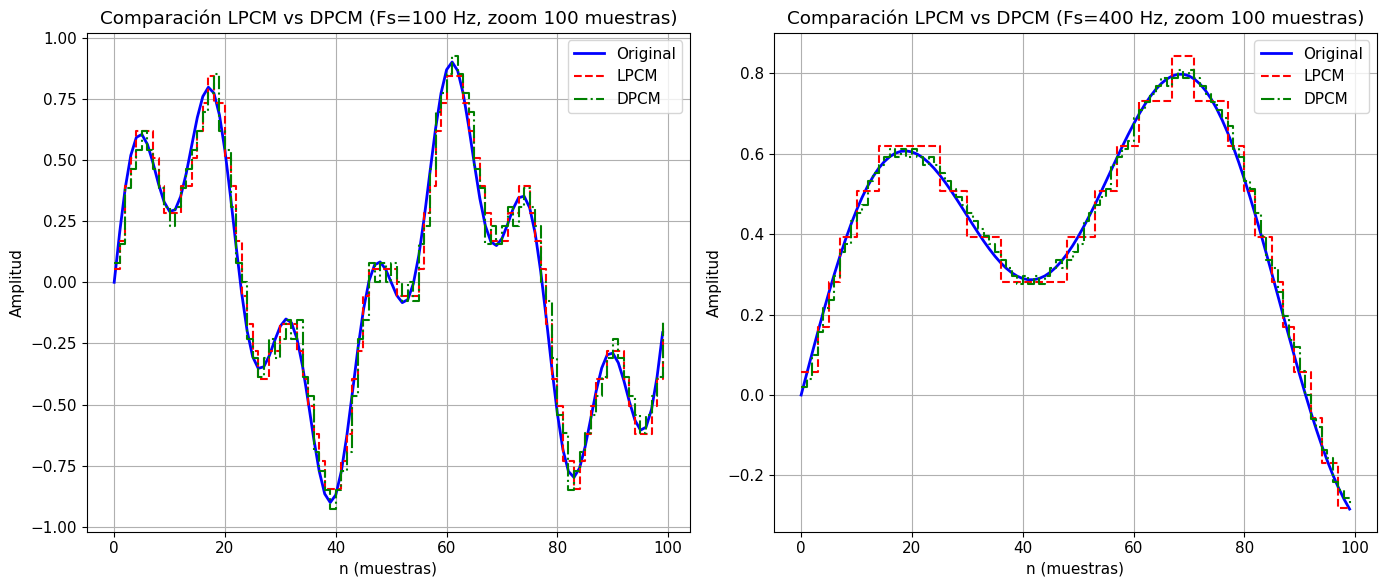

In [12]:
# Visualización comparativa (primeras 100 muestras) superponiendo en la misma gráfica la señal original x (con plot normal) y
# x_lpcm y x_dpcm (plot con drawstyle="steps-post"))
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(n_100[:100], x_100[:100], 'b-', label='Original', linewidth=2)
plt.plot(n_100[:100], x_lpcm_100[:100], 'r--', label='LPCM', drawstyle="steps-post", linewidth=1.5)
plt.plot(n_100[:100], x_dpcm_100[:100], 'g-.', label='DPCM', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Comparación LPCM vs DPCM (Fs={F_s100} Hz, zoom 100 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_400[:100], x_400[:100], 'b-', label='Original', linewidth=2)
plt.plot(n_400[:100], x_lpcm_400[:100], 'r--', label='LPCM', drawstyle="steps-post", linewidth=1.5)
plt.plot(n_400[:100], x_dpcm_400[:100], 'g-.', label='DPCM', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Comparación LPCM vs DPCM (Fs={F_s400} Hz, zoom 100 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿DPCM es mejor a LPCM? Razona la respuesta.**

*Tu respuesta:*

```
En señales con alta correlación temporal, DPCM suele ser mejor que LPCM. Esto ocurre porque DPCM cuantifica la diferencia entre muestras consecutivas, que tiene un rango dinámico menor que la señal original. Al cuantificar valores más pequeños con el mismo número de bits se reduce el error de cuantificación y mejora la SQNR.
```

**2. ¿Qué rango elegiste para cuantificar la señal diferencia y por qué es menor que el rango de la señal?**

*Tu respuesta:*

```
El rango elegido fue, d_range = max(|x[n] - x[n-1]|) * 1.5
Este rango es menor que el de la señal original porque las muestras consecutivas de una señal suave cambian poco. La diferencia entre muestras tiene un rango dinámico mucho más pequeño.
```

**3. ¿Beneficia tener una frecuencia de muestreo más alta (400 Hz) en DPCM? Razona la respuesta.**


*Tu respuesta:*

```
Sí, al aumentar la frecuencia de muestreo, las muestras consecutivas están más próximas en el tiempo y se parecen más entre sí. Esto hace que el error de predicción sea más pequeño.
```


**4. ¿Cuándo DPCM podría empeorar respecto a LPCM? (Pista: piensa en señales sin correlación temporal)**

*Tu respuesta:*

```
DPCM puede empeorar cuando la señal no tiene correlación temporal. En esos casos la diferencia entre muestras puede ser tan grande como la señal original, por lo que cuantificar la diferencia no aporta ninguna ventaja.
```

### 🔍 Checkpoint del profesor (Parada 2)

- [ ] LPCM y DPCM implementados con diferente número de bits
- [ ] Métricas calculadas: MSE, SQNR, Rb
- [ ] DPCM muestra ventaja sobre LPCM
- [ ] Explicación de por qué DPCM es mejor para señales correlacionadas

---

## Parte 4: Delta Modulation (DM) — DPCM de 1 bit

### Contexto teórico

Delta Modulation es un caso extremo de DPCM:
- **Solo 1 bit** por muestra: 1 = subir, 0 = bajar
- Paso fijo $\Delta$ (cuánto sube o baja en cada muestra)
- Régimen binario: $R_b = 1 \times F_s = F_s$ bits/segundo (**mucho menor**)
- Predictor acumulativo: $x_q[n] = x_q[n-1] \pm \Delta$

**Problemas típicos:**

| Problema | Causa | Efecto visual |
|----------|-------|---------------|
| **Granular noise** | $\Delta$ muy grande | Oscilación en zonas planas |
| **Slope overload** | $\Delta$ muy pequeño | No puede seguir cambios rápidos |

### Bloque 4 · Implementación de Delta Modulation

---

#### 📝 Hipótesis previa

**Pregunta:** DM usa solo 1 bit por muestra (subir o bajar $\Delta$). Piensa en:
- Si $\Delta$ es muy grande, ¿qué le pasa a la señal reconstruida en zonas donde la señal es constante? La señal reconstruida oscila alrededor del valor real incluso en zonas donde la señal es constante. El sistema sube y baja demasiado en cada muestra.
- Si $\Delta$ es muy pequeño, ¿qué le pasa cuando la señal sube rápidamente? Si delta es muy pequeño, el sistema no puede seguir cambios rápidos de la señal. Esto produce slope overload, donde la señal reconstruida queda atrasada respecto a la señal original.
- ¿Existirá un valor "perfecto" de $\Delta$? No, porque el valor óptimo depende de la pendiente y dinámica de la señal. Un delta grande reduce granular noise pero aumenta slope overload.

---

**Tareas:**
1. Implementa el bucle de DM.
2. Estima un buen valor de $\Delta$ basándote en la pendiente máxima de la señal.
3. Calcula métricas y régimen binario.

In [13]:
# === IMPLEMENTACIÓN ===
def delta_modulation(x, delta):
    """
    Delta Modulation con paso fijo.
    
    Parámetros:
        x: señal original
        delta: paso de cuantificación (cuánto sube o baja)
    
    Retorna:
        x_q: señal reconstruida
        bits: secuencia de bits (1 = subir, 0 = bajar)
    """
    N = len(x)
    x_q = np.zeros(N)
    bits = np.zeros(N, dtype=int)
    
    for i in range(N):
        # TODO: Implementa DM
        # 1. x_prev = x_q[i-1] (o 0 si i==0)
        # 2. Si x[i] >= x_prev: bit=1, x_rec[i] = x_prev + delta
        # 3. Si x[i] < x_prev:  bit=0, x_rec[i] = x_prev - delta
        if i == 0:
            x_prev = 0
        else:
            x_prev = x_q[i-1]
        
        if x[i] >= x_prev:
            bits[i] = 1
            x_q[i] = x_prev + delta
        else:
            bits[i] = 0
            x_q[i] = x_prev - delta
    
    return x_q, bits

In [14]:
delta_dm_100 = delta_dm_400 = 0.04

# TODO: Calcula el régimen binario, Rb_dm_100 y Rb_dm_400 (DM usa 1 bit por muestra)
Rb_dm_100 = F_s100
Rb_dm_400 = F_s400

# TODO: Cuantifica con DM y calcula MSE y SQNR para x_100 y x_400, obteniendo x_dm_100, bits_dm_100, MSE_dm_100, SQNR_dm_100, x_dm_400, bits_dm_400, MSE_dm_400, SQNR_dm_400
x_dm_100, bits_dm_100 = delta_modulation(x_100, delta_dm_100)
x_dm_400, bits_dm_400 = delta_modulation(x_400, delta_dm_400)

MSE_dm_100 = np.mean((x_100 - x_dm_100)**2)
MSE_dm_400 = np.mean((x_400 - x_dm_400)**2)

Px_100 = np.mean(x_100**2)
Px_400 = np.mean(x_400**2)

SQNR_dm_100 = 10*np.log10(Px_100/MSE_dm_100)
SQNR_dm_400 = 10*np.log10(Px_400/MSE_dm_400)

In [15]:
# === VALIDACIÓN ===
assert len(x_dm_100) == len(x_100), "La señal DM debe tener la misma longitud"
assert len(x_dm_400) == len(x_400), "La señal DM debe tener la misma longitud"
assert np.all(np.isfinite(x_dm_100)), "La señal DM no debe contener NaN o Inf"
assert np.all(np.isfinite(x_dm_400)), "La señal DM no debe contener NaN o Inf"
assert Rb_dm_100 == F_s100, "El régimen binario de DM debe ser Fs"
assert Rb_dm_400 == F_s400, "El régimen binario de DM debe ser Fs"

print(f"\n=== Delta Modulation para x_100 ===")
print(f"Régimen binario: {Rb_dm_100} bits/s")
print(f"Delta elegido: {delta_dm_100:.4f}")
print(f"MSE DM: {MSE_dm_100:.6f}")
print(f"SQNR DM: {SQNR_dm_100:.2f} dB")
print("")
print(f"=== Delta Modulation para x_400 ===")
print(f"Régimen binario: {Rb_dm_400} bits/s")
print(f"Delta elegido: {delta_dm_400:.4f}")
print(f"MSE DM: {MSE_dm_400:.6f}")
print(f"SQNR DM: {SQNR_dm_400:.2f} dB")


=== Delta Modulation para x_100 ===
Régimen binario: 100 bits/s
Delta elegido: 0.0400
MSE DM: 0.146370
SQNR DM: 1.99 dB

=== Delta Modulation para x_400 ===
Régimen binario: 400 bits/s
Delta elegido: 0.0400
MSE DM: 0.000971
SQNR DM: 23.77 dB


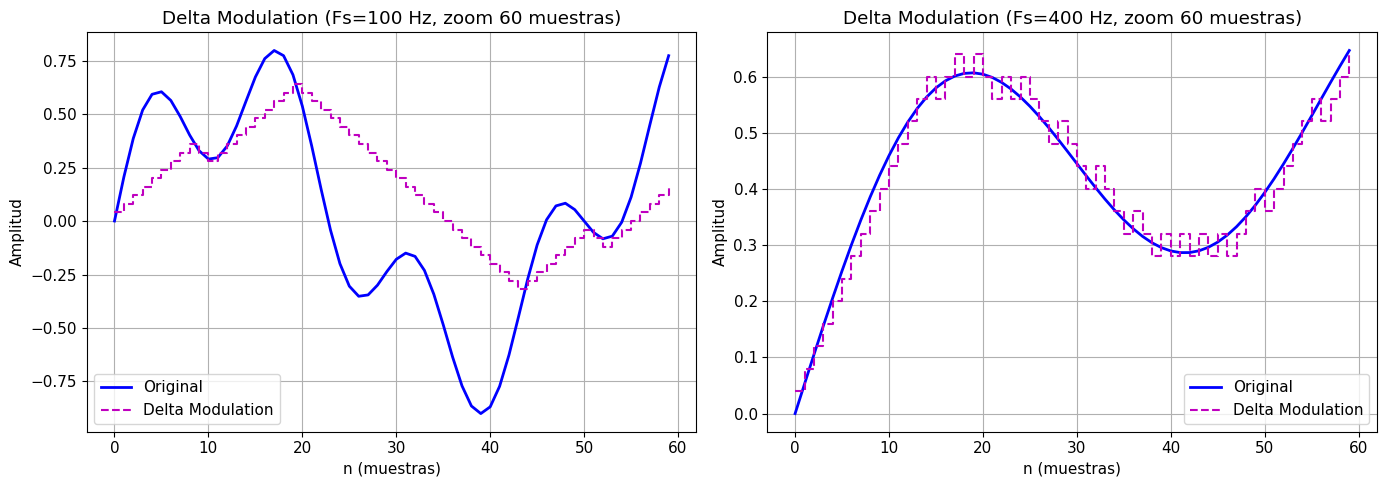

In [16]:
# Visualización (zoom de 60 muestras)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(n_100[:60], x_100[:60], 'b-', label='Original', linewidth=2)
plt.plot(n_100[:60], x_dm_100[:60], 'm--', label='Delta Modulation', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Delta Modulation (Fs={F_s100} Hz, zoom 60 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_400[:60], x_400[:60], 'b-', label='Original', linewidth=2)
plt.plot(n_400[:60], x_dm_400[:60], 'm--', label='Delta Modulation', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Delta Modulation (Fs={F_s400} Hz, zoom 60 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué observas en la cuantificación de la primera señal? ¿Cómo lo solucionarías? (Pista: haz la prueba)**

*Tu respuesta:*

```
En la primera señal, la señal reconstruida no sigue bien los cambios rápidos de la señal original. La aproximación en escalones queda atrasada respecto a la señal real en las zonas donde la pendiente es grande. El paso delta es demasiado pequeño para seguir cambios rápidos, lo que produce slope overload.
```

**2 ¿Qué es mejor una Delta grande o una Delta pequeña? Razona la respuesta.**

*Tu respuesta:*

```
Una delta grande permite seguir mejor cambios rápidos en la señal, pero produce granular noise en zonas donde la señal es casi constante.
Una delta pequeña reduce el granular noise en zonas planas, pero puede provocar slope overload cuando la señal cambia rápidamente.
```

**3. ¿Crees que existe un $\Delta$ "perfecto" para cualquier caso en DM?**

*Tu respuesta:*

```
No, porque el valor óptimo depende de las características de la señal, como su pendiente máxima y su variación temporal.
```

**4. ¿Como afecta la frecuencia de muestreo? ¿Por qué?**

*Tu respuesta:*

```
Una frecuencia de muestreo mayor mejora el rendimiento. Al aumentar, la señal cambia menos entre muestras consecutivas, por lo que el modulador puede seguir mejor la señal incluso con un delta pequeño. Esto reduce el riesgo de slope overload.
```

### 🔍 Checkpoint del profesor (Parada 3)

- [ ] DM implementado y funcionando
- [ ] Tres valores de Δ probados
- [ ] Granular noise y slope overload identificados visualmente
- [ ] Explicación clara del trade-off

---

## Parte 5: Comparativa final

Ahora tienes los tres métodos implementados. Vamos a comparar sus resultados en una tabla

### Bloque 5 · Tabla comparativa

---

#### 📝 Hipótesis previa

**Pregunta:** Antes de ver los números:
- ¿Cuál de los tres métodos tendrá el menor régimen binario $R_b$? DM porque usa 1 bit por muestra.
- ¿Cuál tendrá la mejor SQNR con los mismos bits? DPCM, porque usa la correlación entre muestras para reducir el error.
- ¿Cuál será más "eficiente" (mejor relación calidad/coste)? DPCM, ya que consigue buena SQNR con menos bits que LPCM.

---

In [25]:
# === TABLA COMPARATIVA ===
# TODO: Calcula la eficiencia para cada método (SQNR / (Rb/100)) y cada señal, x_100 y x_400
var_x400 = np.var(x_400)

Rb_dpcm_100 = B_dpcm_100 * F_s100
Rb_dpcm_400 = B_dpcm_400 * F_s400

efic_lpcm_100 = SQNR_lpcm_100 / (Rb_lpcm_100 / 100)
efic_dpcm_100 = SQNR_dpcm_100 / (Rb_dpcm_100 / 100)
efic_dm_100 = SQNR_dm_100 / (Rb_dm_100 / 100)

efic_lpcm_400 = SQNR_lpcm_400 / (Rb_lpcm_400 / 100)
efic_dpcm_400 = SQNR_dpcm_400 / (Rb_dpcm_400 / 100)
efic_dm_400 = SQNR_dm_400 / (Rb_dm_400 / 100)


In [26]:
# Validaciones previas a la tabla comparativa
assert Rb_lpcm_100 == B_lpcm_100 * F_s100
assert Rb_lpcm_400 == B_lpcm_400 * F_s400
assert Rb_dpcm_100 == B_dpcm_100 * F_s100
assert Rb_dpcm_400 == B_dpcm_400 * F_s400
assert Rb_dm_100 == F_s100
assert Rb_dm_400 == F_s400

assert np.isfinite([SQNR_lpcm_100, SQNR_dpcm_100, SQNR_dm_100]).all()
assert np.isfinite([SQNR_lpcm_400, SQNR_dpcm_400, SQNR_dm_400]).all()
assert np.isfinite([efic_lpcm_100, efic_dpcm_100, efic_dm_100]).all()
assert np.isfinite([efic_lpcm_400, efic_dpcm_400, efic_dm_400]).all()

assert MSE_lpcm_100 > 0 and MSE_dpcm_100 > 0 and MSE_dm_100 > 0
assert MSE_lpcm_400 > 0 and MSE_dpcm_400 > 0 and MSE_dm_400 > 0
assert efic_lpcm_100 > 0 and efic_dpcm_100 > 0 and efic_dm_100 > 0
#assert efic_lpcm_400 > 0 and efic_dpcm_400 > 0 and efic_dm_400 > 0
print("=" * 70)
print("COMPARATIVA DE MÉTODOS PCM para x_100")
print("=" * 70)
print(f"{'Método':<15} {'Bits/muestra':>12} {'Rb (bits/s)':>12} {'SQNR (dB)':>12} {'Eficiencia':>12}")
print("-" * 70)
print(f"{'LPCM':<15} {B_lpcm_100:>12} {Rb_lpcm_100:>12} {SQNR_lpcm_100:>12.2f} {efic_lpcm_100:>12.3f}")
print(f"{'DPCM':<15} {B_dpcm_100:>12} {Rb_dpcm_100:>12} {SQNR_dpcm_100:>12.2f} {efic_dpcm_100:>12.3f}")
print(f"{'DM':<15} {1:>12} {Rb_dm_100:>12} {SQNR_dm_100:>12.2f} {efic_dm_100:>12.3f}")
print("=" * 70)
print("(Eficiencia = dB de SQNR por cada 100 bits/s)")

print("\n" + "=" * 70)
print("COMPARATIVA DE MÉTODOS PCM para x_400")
print("=" * 70)
print(f"{'Método':<15} {'Bits/muestra':>12} {'Rb (bits/s)':>12} {'SQNR (dB)':>12} {'Eficiencia':>12}")
print("-" * 70)
print(f"{'LPCM':<15} {B_lpcm_400:>12} {Rb_lpcm_400:>12} {SQNR_lpcm_400:>12.2f} {efic_lpcm_400:>12.3f}")
print(f"{'DPCM':<15} {B_dpcm_400:>12} {Rb_dpcm_400:>12} {SQNR_dpcm_400:>12.2f} {efic_dpcm_400:>12.3f}")
print(f"{'DM':<15} {1:>12} {Rb_dm_400:>12} {SQNR_dm_400:>12.2f} {efic_dm_400:>12.3f}")
print("=" * 70)
print("(Eficiencia = dB de SQNR por cada 100 bits/s)")  

COMPARATIVA DE MÉTODOS PCM para x_100
Método          Bits/muestra  Rb (bits/s)    SQNR (dB)   Eficiencia
----------------------------------------------------------------------
LPCM                       4          400         0.10        0.025
DPCM                       2          200         0.07        0.033
DM                         1          100         1.99        1.994
(Eficiencia = dB de SQNR por cada 100 bits/s)

COMPARATIVA DE MÉTODOS PCM para x_400
Método          Bits/muestra  Rb (bits/s)    SQNR (dB)   Eficiencia
----------------------------------------------------------------------
LPCM                       4         1600         0.05        0.003
DPCM                       2          800        -0.00       -0.000
DM                         1          400        23.77        5.944
(Eficiencia = dB de SQNR por cada 100 bits/s)


### ✍️ Respuestas (OBLIGATORIA)

> **1. Suponiendo que entre 20~23 dB de SQNR tenemos una buena calidad percibida, ¿qué esquema de codificación es más eficiente?**

Basándote en tus experimentos, responde: El método más eficiente es DPCM, ya que logra una buena calidad utilizando un régimen binario menos que LPCM.

**2. ¿Por qué ese método es más eficiente para esta señal en particular?**

*Tu respuesta:*

```
DPCM es más eficiente porque la señal tiene alta correlación temporal, las muestras consecutivas son muy parecidas.
En lugar de codificar la señal completa como LPCM, DPCM codifica la diferencia entre muestras, que tiene menor variación y puede representarse con menos bits.
```

**3. ¿Sería el mismo resultado con una señal de ruido blanco (sin correlación temporal)? ¿Por qué?**

*Tu respuesta:*

```
No, con ruido blanco las muestras no están correlacionadas, porque la diferencia entre muestras no es más pequeña que la señal original. En ese caso DPCM perdería su ventaja y su rendimiento sería similar opeor que LPCM.
```

---

## Preguntas de control

Responde cada pregunta en 2–4 líneas:

### P1. ¿Por qué DPCM puede mejorar LPCM en señales con correlación temporal?

*Tu respuesta:*

```
DPCM codifica la diferencia entre muestras consecutivas en lugar del valor absoluto de la señal.
Si la señal tiene correlación temporal, las diferencias suelen ser pequeñas y con menor varianza.
Esto permite usar menos bits para representar el error, mejorando la calidad respecto a LPCM.
```

---

### P2. ¿Como influye el tamaño del escalón en DM? ¿Cómo compensarías el efecto de un escalón pequeño?

*Tu respuesta:*

```
El tamaño del escalón determina cuánto cambia la señal reconstruida en cada muestra. Si el escalón es demasiado pequeño aparece slope overload, donde el modulador no sigue cambios rápidos.
Para compensarlo se puede aumentar el tamaño del escalón o usar delta modulation adaptativa.
```

---

### P3. Si mantienes el mismo bitrate total (bits/segundo), ¿qué trade-off aparece entre $B$ y $F_s$?

*Tu respuesta:*

```
El bitrate depende de la relación entre frecuencia de muestreo y bits por muestra: R_b = B * F_s.
Si el bitrate es constante, aumentar Fs obliga a reducir B. Si aumentas B, debes reducir Fs.
```

---

---

## ✅ Checklist final

Antes de entregar, verifica:

- [ ] El notebook ejecuta completo sin errores (`Run All`)
- [ ] Las figuras están correctamente etiquetadas (título, ejes, leyenda si procede)
- [ ] Todos los `assert` pasan sin errores
- [ ] LPCM, DPCM y DM implementados y funcionando
- [ ] Tabla comparativa con métricas
- [ ] Las explicaciones están completas y son razonadas
- [ ] Las preguntas de control están respondidas

---

## 🚀 Extensiones sugeridas, opcional

Si terminas antes, intenta esto para profundizar:

### 1. DM con delta adaptada a la pendiente máxima de la señal
Para adaptar $\Delta$ mejor a la pendiente de la señal, debe ser mayor que la pendiente máxima de la señal: $\Delta > \text{pendiente máxima} = \max\left|\frac{dx}{dn}\right| \approx \max|x[n] - x[n-1]|$. Por ejemplo, podrías probar con $\Delta = 1.2 \times \max|x[n] - x[n-1]|$. ¿Mejora el seguimiento de la señal?

### 2. DM adaptativo (ADM)
Implementa un $\Delta$ que varíe: si el bit anterior fue igual al actual, duplica $\Delta$; si no, divídelo por 2. ¿Mejora el seguimiento de la señal?


---

## 📚 Resumen de conceptos clave

| Concepto | Definición corta |
|----------|------------------|
| **PCM** | Pulse Code Modulation: familia de métodos de codificación digital |
| **LPCM** | Linear PCM: cuantifica cada muestra directamente ($B$ bits/muestra) |
| **DPCM** | Differential PCM: cuantifica el error de predicción ($B$ bits/muestra) |
| **DM** | Delta Modulation: DPCM con 1 bit (solo subir/bajar) |
| **Predictor** | Estima la muestra actual a partir de las anteriores |
| **Correlación temporal** | Muestras consecutivas parecidas → error de predicción pequeño |
| **Régimen binario ($R_b$)** | $B \times F_s$ bits/segundo |
| **Granular noise** | Error en DM con $\Delta$ demasiado grande |
| **Slope overload** | Error en DM con $\Delta$ demasiado pequeño |
| **ADPCM** | DPCM con paso adaptativo (varía $\Delta$ según la señal) |

---

**Fin del Taller 4**

*Este taller demuestra que explotar la redundancia temporal de una señal permite representarla con menos bits. En el Taller 5 veremos cómo la **entropía** cuantifica el límite teórico de compresión.*